In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ann
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from typing import Optional, Union, List, Tuple

from scipy.optimize import minimize_scalar, minimize
from scipy.stats import chisquare, binomtest, multinomial, binom, chi2

import warnings
warnings.filterwarnings('ignore')

### Select species for analysis

In [ ]:
#select 'human' or 'chick'

species = 'human' #'chick'

In [ ]:
dir0 = '/Users/volterd/Library/Mobile Documents/com~apple~CloudDocs/postdoc/work/projects/lineage_tracing/'

adata = sc.read_h5ad(dir0 + 'preprocessing_larry_' + species + '_clusters.h5ad')

In [14]:
# load and process cell type-specific dropout tables
prob_col = 'percent_detected' 

if species == 'human':
    drop_df = pd.read_csv(dir0 + 'drop_out_cell_types/human_LARRY_detection_summary_all.csv')
    drop_df[prob_col] = drop_df[prob_col] / 100.0
elif species == 'chick':
    drop_df_t = [pd.read_csv(dir0 + 'drop_out_cell_types/LARRY_detection_summary_'+t_point+'.csv') for t_point in ['HH28','HH31','HH35']]
    drop_df = pd.concat(drop_df_t)
    drop_df[prob_col] = drop_df[prob_col] / 100.0

In [7]:
drop_df[drop_df['Cell.type'].isin(['dI4_dILA','dI5_dILB'])]

,Cell.type,detected,not_detected,total_cells,percent_detected
9,dI4_dILA,2245,1786,4031,0.556934
10,dI5_dILB,1085,573,1658,0.654403


In [40]:
clone_counts = adata.obs['clone'].value_counts()
adata.obs['clone_size'] = adata.obs['clone'].map(clone_counts)
adata.obs['multi_cell_clone'] = np.select(
    [adata.obs['clone_size'] > 1, adata.obs['clone_size'] == 1],
    ["multi_cell_clone", "single_cell_clone"],
    default=np.nan
)

In [41]:
adata.obs['multi_cell_clone'] = adata.obs['multi_cell_clone'].astype('category')

# Probabilistic model fitting

### dI4 - dI5 data

In [ ]:
# subset data to dI4 & dI5 cells from multi-cell clones
di_data = adata[adata.obs['cell_type'].isin(['dI4_dILA', 'dI5_dILB']) & (adata.obs['multi_cell_clone'] == "multi_cell_clone")]

In [209]:
# clone-level summary
clone_summary = di_data.obs.groupby(['clone', 'cell_type']).size().unstack(fill_value=0)
clone_summary['total'] = clone_summary.sum(axis=1)
clones_3 = clone_summary[clone_summary['total'] == 3].copy()
clones_3['ratio'] = clones_3['dI4_dILA'] / 3

In [ ]:
# observed dI4-dI5 compositions in 3-cell clones
clone_summary[clone_summary['total']==3]

cell_type,dI4_dILA,dI5_dILB,total
clone,,,
clone_28_BOE7075A4,1,2,3
clone_55_BOE7075A2,3,0,3
clone_84_BOE7075A2,3,0,3
clone_87_BOE7075A2,0,3,3
clone_87_BOE7075A4,3,0,3
...,...,...,...
clone_1761_BOE7075A2,1,2,3
clone_1949_BOE7075A2,2,1,3
clone_2094_BOE7075A2,2,1,3


In [ ]:
# observed dI4 / (dI4 + dI5) ratios with values in {0, 1/3, 2/3, 1}
observed_counts = np.histogram(clones_3['ratio'], bins=[-0.1, 0.1, 0.4, 0.7, 1.1])[0]
total_n = observed_counts.sum()

### Baseline Binomial model (without dropout)

In [199]:
# Binomial probabilities B(3, 0.5) over bins [0, 1/3, 2/3, 1]
binom_probs = np.array([1/8, 3/8, 3/8, 1/8])

# expected counts under baseline Binomial model
expected_counts_binomial = binom_probs * total_n
print("Expected counts under Binomial model:", expected_counts_binomial)

Expected counts under Binomial model: [11.75 35.25 35.25 11.75]


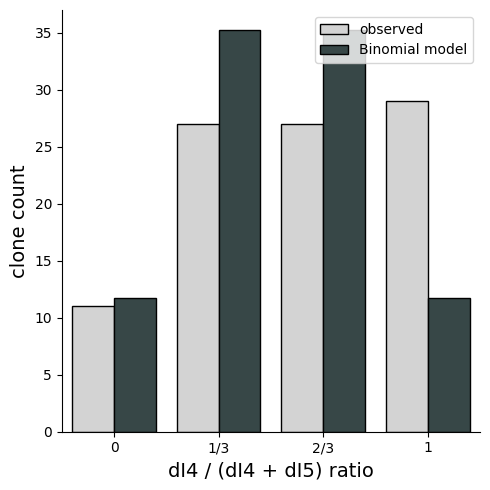

In [ ]:
bins = ['0', '1/3', '2/3', '1']

dist_data = pd.DataFrame({
    'ratio bin': bins * 2,
    'source': ['observed']*4 + ['Binomial model']*4,
    'counts': np.concatenate([observed_counts, expected_counts_binomial])
})

plt.figure(figsize=(5, 5))
ax = sns.barplot(
    data=dist_data,
    x='ratio bin',
    y='counts',
    hue='source',
    palette=['lightgray', 'darkslategrey'],
    saturation = 0.5,
    edgecolor='black'
)

legend = ax.get_legend()
legend.set_title(None)

#plt.title("clonal distribution fit comparison")
plt.xlabel("dI4 / (dI4 + dI5) ratio", fontsize=14)
plt.ylabel("clone count", fontsize=14)
sns.despine()
plt.tight_layout()
plt.savefig(dir0+'probabilistic_model_fit_'+ species +'/Binomial_fit_comparison.pdf', dpi=300)
plt.show()

### General mixture model with dI4 and dI5 bias and technical dropout noise

In [ ]:
# detection probabilities (averaging over timepoints in the case of chick data)
mean_detect_prob = drop_df.groupby('Cell.type')[prob_col].mean().to_dict()

In [ ]:
# look-up function for clone size distribution
def get_p_N(N, N_max, p_N):
    if 3 <= N <= N_max:
        return p_N[N - 3]
    return 0.0


# conditional probabilities of observed compositions in 3-cell clones, marginalising over all possible clone sizes (up to a maximum threshold)
def get_conditional_probs(params, true_states, dropout_matrix, N_max, p_N):
    # stochastic fraction and dI4-committed fraction weights
    alpha_1, alpha_2 = params    
    # dI5-committed fraction weight
    alpha_3 = 1 - alpha_1 - alpha_2  
    
    # true biological distribution of clone compositions
    P_T = np.zeros(len(true_states))
    for row_idx, (t4, t5, N) in enumerate(true_states):
        # stochastic component
        p_stochastic = binom.pmf(t4, N, 0.5)
        # dI4-committed component
        p_dI4_comm = 1.0 if t4 == N else 0.0
        # dI5-committed component
        p_dI5_comm = 1.0 if t4 == 0 else 0.0

        # clone size-dependent biological mixture
        p_bio_mix = (alpha_1 * p_stochastic) + (alpha_2 * p_dI4_comm) + (alpha_3 * p_dI5_comm)
        
        # biological mixture weighted by the empirical size prior p_N
        P_T[row_idx] = p_bio_mix * get_p_N(N, N_max, p_N)
        
    # observation model - marginalising over true clone compositions: true prior model * technical dropout model
    # unnormalised probabilities of 4 possible states in 3-cell clones
    joint_observed_probs = np.dot(P_T, dropout_matrix)
    
    # normalising to get the conditional probabilities of observed 3-cell clone compositions (given clone size = 3) 
    conditional_probs = np.clip(joint_observed_probs / np.sum(joint_observed_probs), 1e-10, 1)

    return conditional_probs

# negative log-likelihood of observed 3-cell clone compositions
def marginalised_neg_log_lik(params, observed_counts, total_n, true_states, dropout_matrix, N_max, p_N):
    conditional_probs = get_conditional_probs(params, true_states, dropout_matrix, N_max, p_N)
    # negative log-likelihood (to be minimised)
    return -multinomial.logpmf(observed_counts, n=total_n, p=conditional_probs)

In [ ]:
#get all possible true dI4-dI5 compositions, given true clone sizes
def get_true_states(N_max, N_min = 3):
    # rows are true combinations, columns are observed bins
    true_states = []
    for N in range(N_min, N_max + 1):
        for t4 in range(N + 1):
            t5 = N - t4
            true_states.append((t4, t5, N))
    return true_states

# Binomial dropout model
def get_dropout_matrix(d4, d5, true_states):
    # Binomial dropouts across the true states (rows) and across the 4 possible states of 3-cell clones (columns)
    dropout_matrix = np.zeros((len(true_states), 4))
    # (k4, k5) are the possible observed states in 3-cell clones
    for row_idx, (t4, t5, N) in enumerate(true_states):
        for k4 in range(4):  
            k5 = 3 - k4      
            # probability that t4 true cells become k4 observed cells after dropout
            p_dI4 = binom.pmf(k4, t4, d4)
            # probability that t5 true cells become k5 observed cells after dropout
            p_dI5 = binom.pmf(k5, t5, d5)

            dropout_matrix[row_idx, k4] = p_dI4 * p_dI5

    return dropout_matrix


In [ ]:
def fit_model(d4, d5, p_N, observed_counts, total_n, N_max = 10, opt_method = 'SLSQP'):
    # retrieve true states
    true_states = get_true_states(N_max)
    # compute dropout matrix under Binomial dropout model
    dropout_matrix = get_dropout_matrix(d4, d5, true_states)

    # define multi-dimensional optimisation task (over alpha_1, alpha_2, alpha_3)
    # alpha_1 and alpha_2 must be between 0 and 1
    bounds = [(0, 1), (0, 1)]
    # constraint: alpha_1 + alpha_2 <= 1 (ensures that alpha_3 >= 0)
    cons = {'type': 'ineq', 'fun': lambda x: 1 - x[0] - x[1]}

    # initial guess: 1/3 for each component
    initial_guess = [0.33, 0.33]

    res = minimize(
        marginalised_neg_log_lik, 
        x0=initial_guess,
        args=(observed_counts, total_n, true_states, dropout_matrix, N_max, p_N),
        bounds=bounds,
        constraints=cons,
        method=opt_method
    )

    return res

In [ ]:
# set maximum threshold of possible true clone sizes
if species == 'human':
    N_max = 6
elif species == 'chick':
    N_max = 10

# empirical clone size prior p(N)
p_N = [np.sum(clone_summary['total'] == s) for s in range(3,N_max+1)]

##### Fit default mixture model without dropout (perfect detection probabilities) - this result is independent of p_N and N_max

In [187]:
d4 = 1.0
d5 = 1.0

res = fit_model(d4, d5, p_N, observed_counts, total_n, N_max)

best_nll_default = res.fun

alpha_1_default, alpha_2_default = res.x
alpha_3_default = 1 - alpha_1_default - alpha_2_default

print(f"Stochastic fraction (alpha_1): {alpha_1_default:.4f}")
print(f"dI4-committed fraction (alpha_2): {alpha_2_default:.4f}")
print(f"dI5-committed fraction (alpha_3): {alpha_3_default:.4f}")

Stochastic fraction (alpha_1): 0.7660
dI4-committed fraction (alpha_2): 0.2128
dI5-committed fraction (alpha_3): 0.0213


In [ ]:
# get expected counts under fitted default model
binom_probs = np.array([1/8, 3/8, 3/8, 1/8])

# calculate pure biological mix vector
expected_probs_default = (
    (alpha_1_default * binom_probs) + 
    (alpha_2_default * np.array([0, 0, 0, 1])) + 
    (alpha_3_default * np.array([1, 0, 0, 0]))
)

# scale probabilities up to counts
expected_counts_default = expected_probs_default * total_n
print("Expected counts under default model:", expected_counts_default)

Expected counts under default model: [10.99999401 27.0000006  27.0000006  29.00000479]


##### Fit mixture model with dropout

In [189]:
# detection probabilities of dI4 / dI5 cells
d4 = mean_detect_prob['dI4_dILA'] 
d5 = mean_detect_prob['dI5_dILB'] 

res = fit_model(d4, d5, p_N, observed_counts, total_n, N_max)

best_nll_noise = res.fun

alpha_1_noise, alpha_2_noise = res.x
alpha_3_noise = 1 - alpha_1_noise - alpha_2_noise

print(f"Corrected stochastic fraction (alpha_1): {alpha_1_noise:.4f}")
print(f"Corrected dI4-committed fraction (alpha_2): {alpha_2_noise:.4f}")
print(f"Corrected dI5-committed fraction (alpha_3): {alpha_3_noise:.4f}")

Corrected stochastic fraction (alpha_1): 0.7253
Corrected dI4-committed fraction (alpha_2): 0.2747
Corrected dI5-committed fraction (alpha_3): 0.0000


In [190]:
# get expected counts under fitted model with technical noise
true_states = get_true_states(N_max)
dropout_matrix = get_dropout_matrix(d4, d5, true_states)

optimal_params_noise = [alpha_1_noise, alpha_2_noise]
expected_probs_noise = get_conditional_probs(optimal_params_noise, true_states, dropout_matrix, N_max, p_N)

# scale probabilities up to counts
expected_counts_noise = expected_probs_noise * total_n
print("Expected counts under technical noise model:", expected_counts_noise)

Expected counts under technical noise model: [11.35117665 28.98147415 24.66486867 29.00248053]


##### Compute empirical 95% confidence intervals of parameter estimates from bootstrapped data

In [ ]:
#Pearson chi-squared
def calc_chisq(obs, exp):
    return np.sum((obs - exp)**2 / exp)

def get_ci(boot_array):
    lower = np.clip(np.quantile(boot_array, 0.25), a_min=0.0, a_max=1.0)
    upper = np.clip(np.quantile(boot_array, 0.975), a_min=0.0, a_max=1.0)
    return lower, upper

In [192]:
n_boot = 10000
boot_alpha_1 = np.zeros(n_boot)
boot_alpha_2 = np.zeros(n_boot)
boot_alpha_3 = np.zeros(n_boot)

constraints = {'type': 'ineq', 'fun': lambda x: 1 - x[0] - x[1]}

for b in range(n_boot):
    # sample synthetic counts from the best-fit model (without noise)
    boot_obs = np.random.multinomial(total_n, expected_probs_default)
    
    # re-optimise on the bootstrap sample
    res_boot = minimize(
        marginalised_neg_log_lik, x0=[0.33, 0.33], 
        args=(boot_obs, total_n, true_states, dropout_matrix, N_max, p_N),
        bounds=[(0,1), (0,1)], constraints=constraints, method='SLSQP')
    
    # extract and store the parameters for this iteration
    alpha_1_opt, alpha_2_opt = res_boot.x
    boot_alpha_1[b] = alpha_1_opt
    boot_alpha_2[b] = alpha_2_opt
    boot_alpha_3[b] = 1 - alpha_1_opt - alpha_2_opt

ci_alpha_1_default = get_ci(boot_alpha_1)
ci_alpha_2_default = get_ci(boot_alpha_2)
ci_alpha_3_default = get_ci(boot_alpha_3)

print(f"Stochastic (α_1) 95% CI: [{ci_alpha_1_default[0]:.4f}, {ci_alpha_1_default[1]:.4f}]")
print(f"dI4-committed (α_2) 95% CI: [{ci_alpha_2_default[0]:.4f}, {ci_alpha_2_default[1]:.4f}]")
print(f"dI5-committed (α_3) 95% CI: [{ci_alpha_3_default[0]:.4f}, {ci_alpha_3_default[1]:.4f}]")

Stochastic (α_1) 95% CI: [0.6735, 0.8324]
dI4-committed (α_2) 95% CI: [0.2351, 0.3898]
dI5-committed (α_3) 95% CI: [0.0000, 0.0593]


In [193]:
n_boot = 10000
boot_alpha_1 = np.zeros(n_boot)
boot_alpha_2 = np.zeros(n_boot)
boot_alpha_3 = np.zeros(n_boot)

constraints = {'type': 'ineq', 'fun': lambda x: 1 - x[0] - x[1]}

for b in range(n_boot):
    # sample synthetic counts from the best-fit model (with noise)
    boot_obs = np.random.multinomial(total_n, expected_probs_noise)
    
    # re-optimise on the bootstrap sample
    res_boot = minimize(
        marginalised_neg_log_lik, x0=[0.33, 0.33], 
        args=(boot_obs, total_n, true_states, dropout_matrix, N_max, p_N),
        bounds=[(0,1), (0,1)], constraints=constraints, method='SLSQP'
    )
    
    # extract and store the parameters for this iteration
    alpha_1_opt, alpha_2_opt = res_boot.x
    boot_alpha_1[b] = alpha_1_opt
    boot_alpha_2[b] = alpha_2_opt
    boot_alpha_3[b] = 1 - alpha_1_opt - alpha_2_opt

ci_alpha_1_noise = get_ci(boot_alpha_1)
ci_alpha_2_noise = get_ci(boot_alpha_2)
ci_alpha_3_noise = get_ci(boot_alpha_3)

print(f"Corrected stochastic (α_1) 95% CI: [{ci_alpha_1_noise[0]:.4f}, {ci_alpha_1_noise[1]:.4f}]")
print(f"Corrected dI4-committed (α_2) 95% CI: [{ci_alpha_2_noise[0]:.4f}, {ci_alpha_2_noise[1]:.4f}]")
print(f"Corrected dI5-committed (α_3) 95% CI: [{ci_alpha_3_noise[0]:.4f}, {ci_alpha_3_noise[1]:.4f}]")

Corrected stochastic (α_1) 95% CI: [0.6693, 0.8324]
Corrected dI4-committed (α_2) 95% CI: [0.2353, 0.3903]
Corrected dI5-committed (α_3) 95% CI: [0.0000, 0.0643]


##### Predictions of mixture models with / without dropout

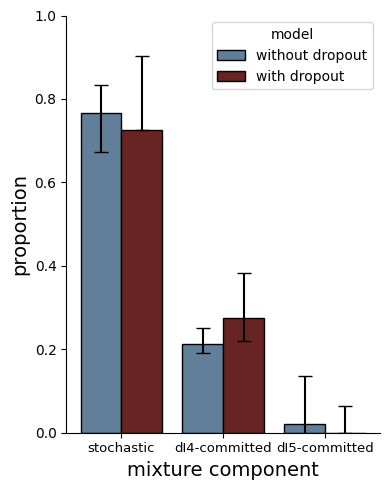

In [ ]:
param_data = pd.DataFrame({
    'mixture component': ['stochastic', 'dI4-committed', 'dI5-committed',
                  'stochastic', 'dI4-committed', 'dI5-committed'],
    'model': ['without dropout', 'without dropout', 'without dropout',
                  'with dropout', 'with dropout', 'with dropout'],
    'fraction': [alpha_1_default, alpha_2_default, alpha_3_default,
                 alpha_1_noise, alpha_2_noise, alpha_3_noise], 
    'CI_lower': [ci_alpha_1_default[0], ci_alpha_2_default[0], ci_alpha_3_default[0],
                 ci_alpha_1_noise[0], ci_alpha_2_noise[0], ci_alpha_3_noise[0]],
    'CI_upper': [ci_alpha_1_default[1], ci_alpha_2_default[1], ci_alpha_3_default[1],
                 ci_alpha_1_noise[1], ci_alpha_2_noise[1], ci_alpha_3_noise[1]],
})

param_data['err_lower'] = param_data['fraction'] - param_data['CI_lower']
param_data['err_upper'] = param_data['CI_upper'] - param_data['fraction']

plt.figure(figsize=(4, 5))
ax = sns.barplot(
    data=param_data, 
    x='mixture component', 
    y='fraction', 
    hue='model', 
    palette=['steelblue', 'darkred'],
    saturation=0.5,
    edgecolor='black'
)

bars = [bar for bar in ax.patches if bar.get_height() > 0 or bar.get_width() > 0]

bars = sorted(bars, key=lambda b: b.get_x())

for i, bar in enumerate(bars):
    if i < len(param_data):
        row = param_data.iloc[i]
 
        err_low = np.max([row['fraction'] - row['CI_lower'],0.0])
        err_up = np.min([row['CI_upper'] - row['fraction'],1.0])
        
        x_center = bar.get_x() + bar.get_width() / 2
        y_top = bar.get_height()
        
        ax.errorbar(
            x_center, 
            y_top, 
            yerr=[[err_low], [err_up]], 
            fmt='none', 
            c='black', 
            capsize=5, 
            zorder=3
        )

ax.tick_params(axis='x', labelsize=9.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("proportion", fontsize=14)
ax.set_xlabel("mixture component", fontsize=14)
sns.despine()
plt.tight_layout()
plt.savefig(dir0+'probabilistic_model_fit_' + species + '/parameter_comparison.pdf', dpi=300)
plt.show()

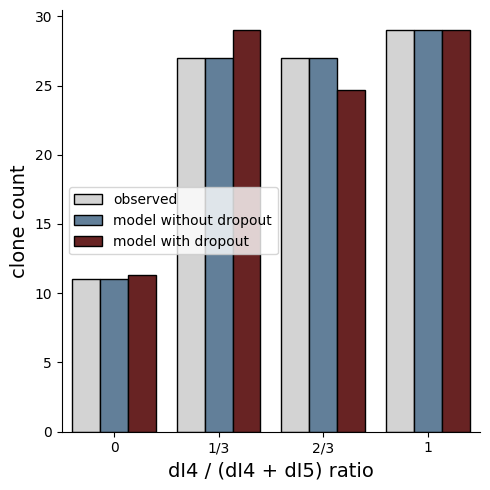

In [ ]:
bins = ['0', '1/3', '2/3', '1']

dist_data = pd.DataFrame({
    'ratio bin': bins * 3,
    'source': ['observed']*4 + ['model without dropout']*4 + ['model with dropout']*4,
    'counts': np.concatenate([observed_counts, expected_counts_default, expected_counts_noise])
})

plt.figure(figsize=(5, 5))
ax = sns.barplot(
    data=dist_data,
    x='ratio bin',
    y='counts',
    hue='source',
    palette=['lightgray', 'steelblue', 'darkred'],
    saturation = 0.5,
    edgecolor='black'
)

legend = ax.get_legend()
legend.set_title(None)
ax.legend(loc='center left')

plt.xlabel("dI4 / (dI4 + dI5) ratio", fontsize=14)
plt.ylabel("clone count", fontsize=14)
sns.despine()
plt.tight_layout()
plt.savefig(dir0+'probabilistic_model_fit_' + species + '/distribution_fit_comparison.pdf', dpi=300)
plt.show()

##### Dependence of log-likelihood on stochastic component weight

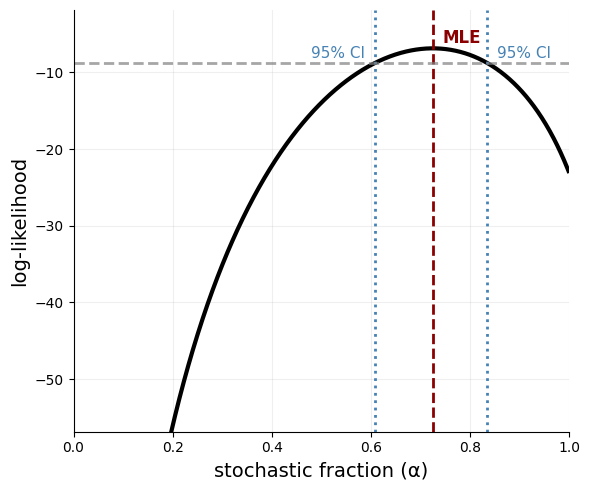

In [ ]:
# retrieve true states
true_states = get_true_states(N_max)

d4 = mean_detect_prob['dI4_dILA'] 
d5 = mean_detect_prob['dI5_dILB'] 
dropout_matrix = get_dropout_matrix(d4, d5, true_states)

a_1_grid = np.linspace(0.001, 0.999, 1000)
ll = np.zeros_like(a_1_grid)

for i, a_1 in enumerate(a_1_grid):
    a_2 = 1.0 - a_1
    ll[i] = - marginalised_neg_log_lik([a_1, a_2], observed_counts, total_n, true_states, dropout_matrix, N_max, p_N)

max_idx = np.argmax(ll)
mle_corrected = a_1_grid[max_idx]
max_ll = ll[max_idx]

ci_threshold = max_ll - 1.92
ci_idx = np.where(ll >= ci_threshold)[0]
lower_ci = a_1_grid[ci_idx[0]]
upper_ci = a_1_grid[ci_idx[-1]]

plt.figure(figsize=(6, 5))

plt.plot(a_1_grid, ll, color='black', linewidth=3)

plt.axvline(mle_corrected, color='darkred', linestyle='--', linewidth=2, label=f'MLE ({mle_corrected:.2f})')
plt.axvline(lower_ci, color='steelblue', linestyle=':', linewidth=2)
plt.axvline(upper_ci, color='steelblue', linestyle=':', linewidth=2, label='95% CI Line')
plt.axhline(ci_threshold, color='grey', linestyle='--', linewidth=2, alpha=0.7)

plt.text(mle_corrected + 0.02, max_ll + (abs(max_ll)*0.1), 'MLE', 
         color='darkred', fontsize=12, ha='left', weight='bold')
plt.text(lower_ci - 0.02, ci_threshold + (abs(max_ll)*0.1), '95% CI', 
         color='steelblue', fontsize=11, ha='right')
plt.text(upper_ci + 0.02, ci_threshold + (abs(max_ll)*0.1), '95% CI', 
         color='steelblue', fontsize=11, ha='left')

plt.xlim(0, 1.0)
plt.ylim(max_ll - 50, max_ll + 5) 

plt.xlabel('stochastic fraction (α)', fontsize=14)
plt.ylabel('log-likelihood', fontsize=14)
plt.grid(True, linestyle='-', alpha=0.2)
sns.despine()
plt.tight_layout()
plt.savefig(dir0 + 'probabilistic_model_fit_' + species + '/likelihood_profile_alpha_noise.pdf', dpi=300)
plt.show()

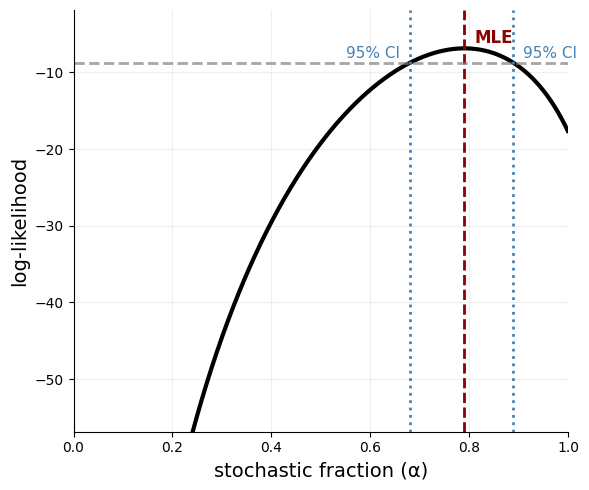

In [ ]:
# retrieve true states
true_states = get_true_states(N_max)

# perfect detection probabilities
d4 = 1.0 
d5 = 1.0 
dropout_matrix = get_dropout_matrix(d4, d5, true_states)

a_1_grid = np.linspace(0.001, 0.999, 1000)
ll = np.zeros_like(a_1_grid)

for i, a_1 in enumerate(a_1_grid):
    a_2 = 1.0 - a_1
    ll[i] = - marginalised_neg_log_lik([a_1, a_2], observed_counts, total_n, true_states, dropout_matrix, N_max, p_N)

max_idx = np.argmax(ll)
mle_corrected = a_1_grid[max_idx]
max_ll = ll[max_idx]

# Define the 95% Confidence Interval cutoff line (Likelihood Ratio Method)
ci_threshold = max_ll - 1.92
ci_idx = np.where(ll >= ci_threshold)[0]
lower_ci = a_1_grid[ci_idx[0]]
upper_ci = a_1_grid[ci_idx[-1]]

plt.figure(figsize=(6, 5))

plt.plot(a_1_grid, ll, color='black', linewidth=3)

plt.axvline(mle_corrected, color='darkred', linestyle='--', linewidth=2, label=f'MLE ({mle_corrected:.2f})')
plt.axvline(lower_ci, color='steelblue', linestyle=':', linewidth=2)
plt.axvline(upper_ci, color='steelblue', linestyle=':', linewidth=2, label='95% CI Line')
plt.axhline(ci_threshold, color='grey', linestyle='--', linewidth=2, alpha=0.7)

# Text overlays matching your screenshot format
plt.text(mle_corrected + 0.02, max_ll + (abs(max_ll)*0.1), 'MLE', 
         color='darkred', fontsize=12, ha='left', weight='bold')
plt.text(lower_ci - 0.02, ci_threshold + (abs(max_ll)*0.1), '95% CI', 
         color='steelblue', fontsize=11, ha='right')
plt.text(upper_ci + 0.02, ci_threshold + (abs(max_ll)*0.1), '95% CI', 
         color='steelblue', fontsize=11, ha='left')

plt.xlim(0, 1.0)
plt.ylim(max_ll - 50, max_ll + 5) 

plt.xlabel('stochastic fraction (α)', fontsize=14)
plt.ylabel('log-likelihood', fontsize=14)
plt.grid(True, linestyle='-', alpha=0.2)
sns.despine()
plt.tight_layout()
plt.savefig(dir0 + 'probabilistic_model_fit' + species + '/likelihood_profile_alpha_default.pdf', dpi=300)
plt.show()

##### Chi-squared goodness-of-fit tests

In [170]:
n_boot = 10000
constraints = {'type': 'ineq', 'fun': lambda x: 1 - x[0] - x[1]}

# goodness-of-fit for baseline Binomial 
actual_chisq_binomial = calc_chisq(observed_counts, expected_counts_binomial)

boot_chisqs_binomial = []
for b in range(n_boot):
    boot_obs = np.random.multinomial(total_n, binom_probs)
    boot_chisqs_binomial.append(calc_chisq(boot_obs, expected_counts_binomial))


# goodness-of-fit for model without dropout noise
# perfect detection probabilities
d4 = 1.0 
d5 = 1.0 
dropout_matrix = get_dropout_matrix(d4, d5, true_states)

actual_chisq_default = calc_chisq(observed_counts, expected_counts_default)

boot_chisqs_default = []
for b in range(n_boot):
    boot_obs = np.random.multinomial(total_n, expected_probs_default)
    
    res_boot = minimize(marginalised_neg_log_lik, x0=[0.33, 0.33], 
                        args=(boot_obs, total_n, true_states, dropout_matrix, N_max, p_N),
                        bounds=[(0,1), (0,1)], constraints=constraints, method='SLSQP')
    
    boot_exp_counts = get_conditional_probs(res_boot.x, true_states, dropout_matrix, N_max, p_N) * total_n
    boot_chisqs_default.append(calc_chisq(boot_obs, boot_exp_counts))

# goodness-of-fit for model with dropout noise
# detection probabilities of dI4 / dI5 cells
d4 = mean_detect_prob['dI4_dILA'] 
d5 = mean_detect_prob['dI5_dILB'] 
dropout_matrix = get_dropout_matrix(d4, d5, true_states)

actual_chisq_noise = calc_chisq(observed_counts, expected_counts_noise)

boot_chisqs_noise = []
for b in range(n_boot):
    boot_obs = np.random.multinomial(total_n, expected_probs_noise)

    res_boot = minimize(marginalised_neg_log_lik, x0=[0.33, 0.33], 
                        args=(boot_obs, total_n, true_states, dropout_matrix, N_max, p_N),
                        bounds=[(0,1), (0,1)], constraints=constraints, method='SLSQP')
    
    boot_exp_counts = get_conditional_probs(res_boot.x, true_states, dropout_matrix, N_max, p_N) * total_n
    boot_chisqs_noise.append(calc_chisq(boot_obs, boot_exp_counts))


# empirical p-values
p_binomial = (np.sum(np.array(boot_chisqs_binomial) >= actual_chisq_binomial) + 1) / (n_boot + 1)
p_default = (np.sum(np.array(boot_chisqs_default) >= actual_chisq_default) + 1) / (n_boot + 1)
p_noise = (np.sum(np.array(boot_chisqs_noise) >= actual_chisq_noise) + 1) / (n_boot + 1)

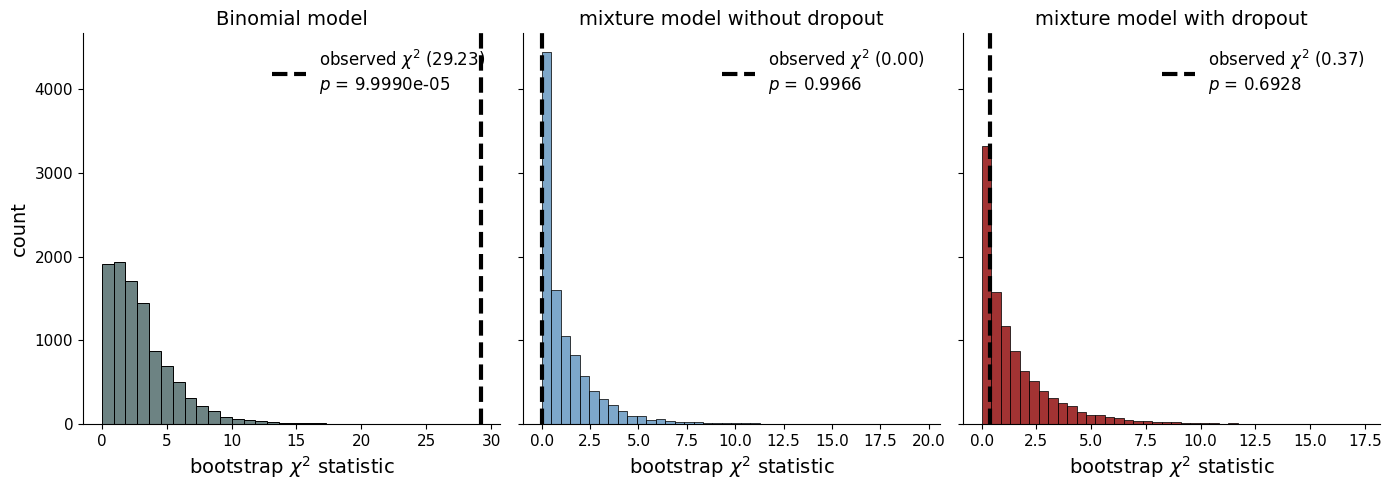

In [ ]:
plot_df = pd.DataFrame({
    'ChiSq': np.concatenate([boot_chisqs_binomial, boot_chisqs_default, boot_chisqs_noise]),
    'model': ['pure binomial']*n_boot + ['without dropout']*n_boot + ['with dropout']*n_boot
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

sns.histplot(
    data=plot_df[plot_df['model'] == 'pure binomial'], 
    x='ChiSq', ax=axes[0], color='darkslategrey', bins=30, alpha=0.7
)
axes[0].axvline(actual_chisq_binomial, color='black', linestyle='--', linewidth=3, 
                label=f'observed $\chi^2$ ({actual_chisq_binomial:.2f})\n$p$ = {p_binomial:.4e}')
axes[0].set_title("Binomial model", fontsize=14)
axes[0].set_xlabel(r"bootstrap $\chi^2$ statistic", fontsize=14)
axes[0].set_ylabel('count', fontsize=14)
axes[0].legend(loc='upper right', frameon=False, fontsize=12)


sns.histplot(
    data=plot_df[plot_df['model'] == 'without dropout'], 
    x='ChiSq', ax=axes[1], color='steelblue', bins=40, alpha=0.7
)
axes[1].axvline(actual_chisq_default, color='black', linestyle='--', linewidth=3, 
                label=f'observed $\chi^2$ ({actual_chisq_default:.2f})\n$p$ = {p_default:.4f}')
axes[1].set_title("mixture model without dropout", fontsize=14)
axes[1].set_xlabel(r"bootstrap $\chi^2$ statistic", fontsize=14)
axes[1].set_ylabel("count", fontsize=14)
axes[1].legend(loc='upper right', frameon=False, fontsize=12)


sns.histplot(
    data=plot_df[plot_df['model'] == 'with dropout'], 
    x='ChiSq', ax=axes[2], color='darkred', bins=40, alpha=0.8,
)
axes[2].axvline(actual_chisq_noise, color='black', linestyle='--', linewidth=3, 
                label=f'observed $\chi^2$ ({actual_chisq_noise:.2f})\n$p$ = {p_noise:.4f}')
axes[2].set_title("mixture model with dropout", fontsize=14)
axes[2].set_xlabel(r"bootstrap $\chi^2$ statistic", fontsize=14)
axes[2].legend(loc='upper right', frameon=False, fontsize=12)

for ax in axes:
    ax.tick_params(axis='both', labelsize=11)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(dir0 + 'probabilistic_model_fit_' + species + '/bootstrapped_goodness_of_fit.pdf', dpi=300)
plt.show()

### 